In [2]:


# Preparation
import numpy as np

from sklearn.datasets import load_iris
iris = load_iris()

X = iris.data
X = X[:, [2,3]]     # iris can be classified by this feature
y = iris.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X[(y==0) | (y==1)],
    y[(y==0) | (y==1)],
    test_size=0.3,
    random_state=0
)

In [3]:

# Learning Phase
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(C=1e4, random_state=123, solver='lbfgs')

lr.fit(X_train, y_train)


# Prediction
y_pred = lr.predict(X_test)


## see results
X_test
lr.coef_    # params
lr.predict_proba(X_test)    # probability of belongings
lr.predict_proba(X_test).argmax(axis=1), lr.predict(X_test)


(array([0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 1, 0, 0, 0, 1, 1, 1]),
 array([0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 1, 0, 0, 0, 1, 1, 1]))

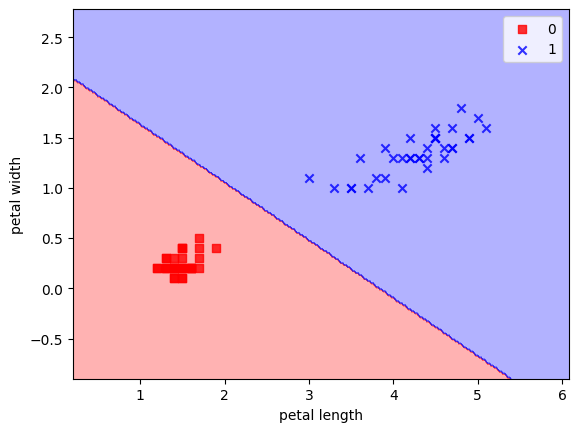

In [4]:



## Visualization
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from ml_lib.fig_func import plot_decision_regions


# learning result
plot_decision_regions(X=X_train, y=y_train, classifier=lr)
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.legend()

plt.show()

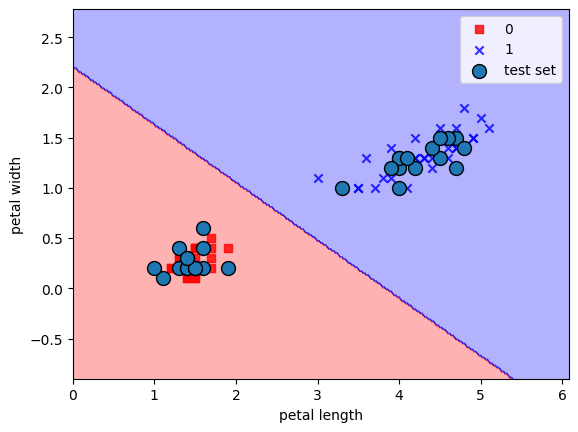

In [5]:

# Predicion result
plot_decision_regions(X=np.concatenate([X_train, X_test]),
                     y=np.concatenate([y_train, y_test]),
                     classifier=lr,
                     test_idx=range(70, 100))
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.legend()

plt.show()

In [6]:

# confusion_matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
tn, fp, fn, tp = cm.flatten()

print(tn)   # True Negative
print(fp)   # False Positive (truth is negative)
print(fn)   # False Negative (truth is positive)
print(tp)   # True Positive




[[15  0]
 [ 0 15]]
15
0
0
15
